# SynapseMNIST3D synapse classification

## Overview

Classify 28x28x28 electron-microscopy volumes as inhibitory (label 0, the minority) or excitatory (label 1). Train / val / test is 1,230 / 177 / 352 volumes. Inhibitory is 27% of both train (331) and test (95).

Arms:
- Baseline: 2.5D ResNet-18 + `BCEWithLogitsLoss` + Adam, no augmentation, no balancing.
- Models 1 to 4: 2.5D ResNet-20 + LibAUC `AUCMLoss_V2` + `PESG` + `DualSampler`, hand-picked hyperparameters, four augmentation sets (flip + noise, flip + rotate, noise + elastic, all four).
- No-augmentation ablation: the Model 1 recipe without augmentation.
- Hand-picked Conv3d: `r3d_18` (true 3D convolution, from scratch) with the Model 4 recipe.
- Optuna-tuned Conv3d: the same model after a 30-trial search.

Only the Baseline and the Optuna-tuned Conv3d have every metric, and the tuned Conv3d is better on all but inhibitory recall (0.39 vs. 0.53). It also has the highest test ROC-AUC (0.78), close to Model 4 and the hand-picked Conv3d (both 0.76). Arms with 3D rotation score 0.74 to 0.78, arms without it 0.58 to 0.64, about the same as the Baseline (0.63). True 3D convolution shows no clear gain over Model 4, and 13 of 30 Optuna trials scored below 0.5.

Notes:
- ResNet-18 starts with a 7x7 stride-2 conv and a max-pool, so a 28x28 input is 7x7 before the first stage and 1x1 at the last. ResNet-20 starts with a 3x3 stride-1 conv and no max-pool and ends at 7x7. Both take the 28 depth slices as input channels (2.5D).
- `AUCMLoss_V2` needs both classes in every batch, so `DualSampler` fixes the share of label-1 samples per batch (`sampling_rate`). Label 1 is the majority here, so `sampling_rate=0.5` gives 16 excitatory and 16 inhibitory volumes per batch of 32 (the natural inhibitory share is 27%). The minority is oversampled and an epoch is sized by the majority class.
- Arms train for up to 50 epochs with patience 12. An epoch counts toward patience when its validation ROC-AUC is at most 0.005 above the previous epoch's. The best-validation checkpoint is restored.

In [ ]:
!pip install medmnist libauc==1.2.0 monai optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 15.2 MB/s eta 0:00:00


In [ ]:
import os
os.makedirs('/root/.medmnist', exist_ok=True)
# download from Zenodo with retry/resume, medmnist then finds the file already there
!wget -c --tries=5 --waitretry=15 -O /root/.medmnist/synapsemnist3d.npz "https://zenodo.org/record/6496656/files/synapsemnist3d.npz?download=1"
!md5sum /root/.medmnist/synapsemnist3d.npz

--2026-09-24 09:48:36--  https://zenodo.org/record/6496656/files/synapsemnist3d.npz?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 137.138.153.219, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/6496656/files/synapsemnist3d.npz [following]
--2026-09-24 09:48:37--  https://zenodo.org/records/6496656/files/synapsemnist3d.npz
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 38034583 (36M) [application/octet-stream]
Saving to: ‘/root/.medmnist/synapsemnist3d.npz’

/root/.medmnist/syn 100%[===================>]  36.27M  8.58MB/s    in 6.6s    

2026-09-24 09:48:43 (5.53 MB/s) - ‘/root/.medmnist/synapsemnist3d.npz’ saved [38034583/38034583]

1235b78a3cd6280881dd7850a78eadb6  /root/.medmnist/synapsemnist3d.npz


In [ ]:
from sklearn import metrics
import numpy as np
import torch
import torch.nn as nn
import torch.utils.data as data
from dataCentric_functions import *

import medmnist
from medmnist import INFO

In [ ]:
from libauc.losses import AUCMLoss_V2  # libauc 1.2.0: AUCMLoss_V2 is a separate class (no version= kwarg)
from libauc.optimizers import PESG
from libauc.models import resnet20 as ResNet20
from libauc.sampler import DualSampler
from libauc.metrics import auc_roc_score
from libauc.models import resnet18 as ResNet18

import torch
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import os

# output directory for saved checkpoints
if not os.path.exists('synapse'):
    os.makedirs('synapse')

In [ ]:
data_flag = 'synapsemnist3d'
download = True

BATCH_SIZE = 32  # batch size for all loaders except the Optuna search

info = INFO[data_flag]

DataClass = getattr(medmnist, info['python_class'])

In [ ]:
# no transform: PIL transforms don't support 3D volumes. medmnist then returns a [0, 1]
# array (1, D, H, W), and make_augment (below) turns it into a tensor without the channel dim
data_transform1 = None

In [ ]:
train_dataset1 = DataClass(split='train', transform=data_transform1, download=download)
val_dataset1 = DataClass(split='val', transform=data_transform1, download=download)
test_dataset = DataClass(split='test', transform=data_transform1, download=download)

train_dataset1

Dataset SynapseMNIST3D of size 28 (synapsemnist3d)
    Number of datapoints: 1230
    Root location: /root/.medmnist
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'inhibitory synapse', '1': 'excitatory synapse'}
    Number of samples: {'train': 1230, 'val': 177, 'test': 352}
    Description: The SynapseMNIST3D is a new 3D volume dataset to classify whether a synapse is excitatory or inhibitory. It uses a 3D image volume of an adult rat acquired by a multi-beam scanning electron microscope. The original data is of the size 100×100×100um^3 and the resolution 8×8×30nm^3, where a (30um)^3 sub-volume was used in the MitoEM dataset with dense 3D mitochondria instance segmentation labels. Three neuroscience experts segment a pyramidal neuron within the whole volume and proofread all the synapses on this neuron with excitatory/inhibitory labels. For each labeled synaptic location, we crop a 3D volume of 1024×1024×1024nm^3 and resize it into 28×2

In [ ]:
train_counts = np.unique(train_dataset1.labels, return_counts=True)
val_counts = np.unique(val_dataset1.labels, return_counts=True)
print(f"class ratio (train): {train_counts}")
print(f"class ratio (val): {val_counts}")
print(f"class ratio (test): {np.unique(test_dataset.labels, return_counts=True)}")
# training-split counts (label 0 = inhibitory, label 1 = excitatory)
neg_counts, pos_counts = train_counts[1][0], train_counts[1][1]
print(f"train-only class ratio: {neg_counts, pos_counts}")

class ratio (train): (array([0, 1], dtype=uint8), array([331, 899]))
class ratio (val): (array([0, 1], dtype=uint8), array([ 48, 129]))
class ratio (test): (array([0, 1], dtype=uint8), array([ 95, 257]))
train-only class ratio: (np.int64(331), np.int64(899))


## Data

Label 0 = inhibitory synapse (minority), label 1 = excitatory synapse (majority).

| Split | Inhibitory (0) | Excitatory (1) | Total |
|---|---|---|---|
| Train | 331 | 899 | 1,230 |
| Val | 48 | 129 | 177 |
| Test | 95 | 257 | 352 |

The Baseline trains on this natural distribution. The AUC-margin models rebalance batches with `DualSampler`.

### Training tensors

Volumes are scaled from [0, 255] to [0, 1]. Validation and test volumes get the same scaling.

In [ ]:
# scale 0-255 to [0, 1], same as the test tensors later
ct_tensors_img = torch.from_numpy(train_dataset1.imgs.astype(np.float32) / 255.0)
ct_tensors_labels = torch.from_numpy(train_dataset1.labels)
ct_tensors_img.shape

torch.Size([1230, 28, 28, 28])

## Augmentation building blocks

MONAI 3D transforms, each with its own probability, applied to every training volume whatever its class (augmenting only one class could give the model a shortcut to the label). Validation and test volumes are never augmented.

| Transform | Setting |
|---|---|
| Flip | `RandFlip`, p=0.5, along the depth axis (`spatial_axis=0`) |
| Rotation | `RandRotate`, p=0.5, up to 0.26 rad about each of the three axes, bilinear, zero padding |
| Elastic deformation | `Rand3DElastic`, p=0.3, sigma 3 to 5, displacement 2 to 6 voxels, bilinear, zero padding |
| Gaussian noise | `RandGaussianNoise`, p=0.3, mean 0, std 0.1 |

In [ ]:
# MONAI augmentations (each with its own probability) and a per-model composer
# OnTheFlyAugment (dataCentric_functions.py) redraws the augmentation for every item each epoch
import monai.transforms as mt

def flip_aug(img):
    # flips along the depth axis (spatial_axis=0)
    return mt.RandFlip(prob=0.5, spatial_axis=0)(img)

def rotate_aug(img):
    return mt.RandRotate(range_x=0.26, range_y=0.26, range_z=0.26, prob=0.5,
                          mode="bilinear", padding_mode="zeros")(img)

def elastic_aug(img):
    # magnitude_range is a displacement in voxels
    return mt.Rand3DElastic(sigma_range=(3, 5), magnitude_range=(2, 6), prob=0.3,
                             mode="bilinear", padding_mode="zeros")(img)

def noise_aug(img):
    return mt.RandGaussianNoise(prob=0.3, mean=0.0, std=0.1)(img)

def make_augment(funcs):
    def augment(img):
        # medmnist gives (1, D, H, W), the channel-first layout MONAI expects
        # the channel dim is dropped afterwards so depth becomes the input channels of the 2D CNN
        if isinstance(img, np.ndarray):
            img = torch.from_numpy(img)
        img = img.float()
        for f in funcs:
            img = f(img)
        if img.dim() == 4 and img.shape[0] == 1:
            img = img.squeeze(0)
        return img
    return augment

X_train = ct_tensors_img  # X_train.shape[1] (= depth) sets conv1's input channels

# validation set: raw [0, 1] volumes, never augmented
val_imgs = torch.from_numpy(val_dataset1.imgs.astype(np.float32) / 255.0)
val_labels = torch.from_numpy(val_dataset1.labels)
val_d = torch.utils.data.TensorDataset(val_imgs, val_labels)

## Baseline

2.5D `libauc.models.resnet18` (ImageNet-style stem, see the Overview) from scratch, `BCEWithLogitsLoss` on the raw logit, `torch.optim.Adam` with lr 1e-3 and no decay schedule.
- Raw volumes, no augmentation, plain shuffled loader (no sampler, no class balancing), batch size 32.
- `train_with_logits_loss` validates after the first minibatch of each epoch, so the epoch in its restore message counts full epochs plus one step. The AUC-margin arms validate after each full epoch. It ran all 50 epochs.
- Test metrics: ROC-AUC, confusion matrix, balanced accuracy, PR-AUC (label 1) and MCC.

In [ ]:
# Baseline data: raw volumes, plain shuffled loader, no sampler
train_d_baseline = torch.utils.data.TensorDataset(ct_tensors_img, ct_tensors_labels)
trainloader_baseline = data.DataLoader(dataset=train_d_baseline, batch_size=BATCH_SIZE, shuffle=True)
trainloader_eval_baseline = data.DataLoader(dataset=train_d_baseline, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
valloader_baseline = data.DataLoader(dataset=val_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
# ResNet-18: ImageNet-style stem, see Overview
# conv1 input channels = volume depth
model_baseline = ResNet18(pretrained=False, last_activation=None, num_classes=1)
model_baseline.conv1 = torch.nn.Conv2d(X_train.shape[1], 64, kernel_size=7, stride=2, padding=3, bias=False)

# BCEWithLogitsLoss takes raw logits (sigmoid is applied inside)
loss_fn_baseline = nn.BCEWithLogitsLoss()
lr_baseline = 1e-3
optimizer_baseline = torch.optim.Adam(model_baseline.parameters(), lr=lr_baseline)

# same epochs and patience as the AUC-margin arms, constant lr since
# train_with_logits_loss has no decay_epochs argument
total_epochs_baseline = 50
patience_baseline = 12

In [ ]:
# train_with_logits_loss takes raw logits for the loss (train() applies a sigmoid first)
# restores the best-validation-AUC weights in place, val AUC prints every 400 batches (once per epoch here)
train_with_logits_loss(model_baseline, loss_fn_baseline, optimizer_baseline, total_epochs_baseline,
                       trainloader_baseline, trainloader_eval_baseline, valloader_baseline,
                       patience=patience_baseline)

Start Training
------------------------------
device: cuda
Epoch=0, BatchID=0, Val_AUC=0.5021
0
Epoch=1, BatchID=0, Val_AUC=0.6074
0
Epoch=2, BatchID=0, Val_AUC=0.5249
1
Epoch=3, BatchID=0, Val_AUC=0.5152
2
Epoch=4, BatchID=0, Val_AUC=0.5092
3
Epoch=5, BatchID=0, Val_AUC=0.6591
0
Epoch=6, BatchID=0, Val_AUC=0.6339
1
Epoch=7, BatchID=0, Val_AUC=0.6422
0
Epoch=8, BatchID=0, Val_AUC=0.5942
1
Epoch=9, BatchID=0, Val_AUC=0.5604
2
Epoch=10, BatchID=0, Val_AUC=0.5774
0
Epoch=11, BatchID=0, Val_AUC=0.6105
0
Epoch=12, BatchID=0, Val_AUC=0.6273
0
Epoch=13, BatchID=0, Val_AUC=0.5656
1
Epoch=14, BatchID=0, Val_AUC=0.5459
2
Epoch=15, BatchID=0, Val_AUC=0.5520
0
Epoch=16, BatchID=0, Val_AUC=0.5835
0
Epoch=17, BatchID=0, Val_AUC=0.5814
1
Epoch=18, BatchID=0, Val_AUC=0.5338
2
Epoch=19, BatchID=0, Val_AUC=0.6358
0
Epoch=20, BatchID=0, Val_AUC=0.6045
1
Epoch=21, BatchID=0, Val_AUC=0.6371
0
Epoch=22, BatchID=0, Val_AUC=0.6466
0
Epoch=23, BatchID=0, Val_AUC=0.6156
1
Epoch=24, BatchID=0, Val_AUC=0.5826
2
E

In [ ]:
# recompute the validation AUC of the restored best checkpoint (no logs are returned)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# eval mode: BatchNorm uses running statistics. Training leaves the model in train mode,
# where predictions would depend on batch composition
model_baseline.eval()
val_pred_list_baseline = []
val_true_list_baseline = []
with torch.no_grad():
    for v_data, v_labels in valloader_baseline:
        v_data = v_data.to(device)
        v_pred = torch.sigmoid(model_baseline(v_data))
        val_pred_list_baseline.append(v_pred.cpu().numpy())
        val_true_list_baseline.append(v_labels.numpy())
val_true_baseline = np.concatenate(val_true_list_baseline)
val_pred_baseline = np.concatenate(val_pred_list_baseline)
val_auc_baseline = np.mean(auc_roc_score(val_true_baseline, val_pred_baseline))
print("Validation AUC (baseline, best checkpoint): %.4f" % val_auc_baseline)

Validation AUC (baseline, best checkpoint): 0.6591


In [ ]:
X_test_baseline = torch.from_numpy(test_dataset.imgs.astype(np.float32) / 255.0)
test_d_baseline = torch.utils.data.TensorDataset(X_test_baseline, torch.from_numpy(test_dataset.labels))
test_loader_baseline = data.DataLoader(dataset=test_d_baseline, batch_size=BATCH_SIZE)

# test ROC-AUC (the trainer already moved the model to `device`)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_baseline.eval()  # eval mode: BatchNorm uses running statistics
score_list_baseline = list()
label_list_baseline = list()
for _, d in enumerate(test_loader_baseline, 0):
    tmp_data, tmp_label = d
    tmp_data = tmp_data.to(device)
    # raw logits are fine for ROC-AUC (ranking only)
    tmp_score = model_baseline(tmp_data).detach().clone().cpu()
    score_list_baseline.append(tmp_score)
    label_list_baseline.append(tmp_label.cpu())

test_label_baseline = torch.cat(label_list_baseline)
test_score_baseline = torch.cat(score_list_baseline)

test_auc_baseline = metrics.roc_auc_score(test_label_baseline, test_score_baseline)
print("Test (baseline: resnet18 + BCEWithLogitsLoss + Adam) : %.4f"%test_auc_baseline, flush=True)

Test (baseline: resnet18 + BCEWithLogitsLoss + Adam) : 0.6259


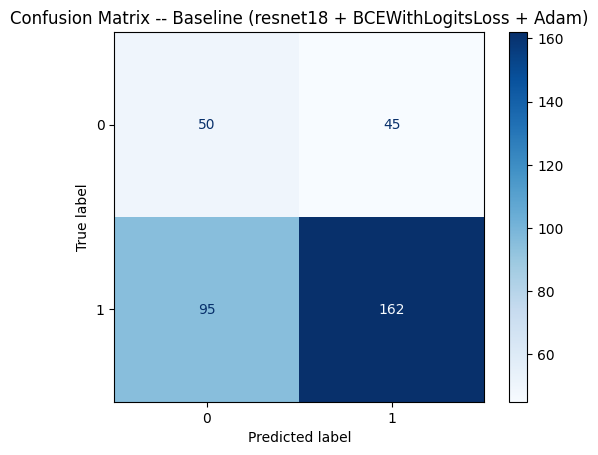

              precision    recall  f1-score   support

           0     0.3448    0.5263    0.4167        95
           1     0.7826    0.6304    0.6983       257

    accuracy                         0.6023       352
   macro avg     0.5637    0.5783    0.5575       352
weighted avg     0.6645    0.6023    0.6223       352

Balanced accuracy: 0.5783
PR-AUC (average precision): 0.8069
Matthews correlation coefficient: 0.1413


In [ ]:
# confusion matrix and threshold metrics at 0.5
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              balanced_accuracy_score, average_precision_score, matthews_corrcoef)

prob = torch.sigmoid(test_score_baseline).numpy().reshape(-1)  # raw logit -> probability
y_true = test_label_baseline.numpy().astype(int).reshape(-1)
y_pred = (prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title('Confusion Matrix -- Baseline (resnet18 + BCEWithLogitsLoss + Adam)')
plt.show()

# class 0 = inhibitory (minority), class 1 = excitatory (majority)
print(classification_report(y_true, y_pred, digits=4))
print('Balanced accuracy: %.4f' % balanced_accuracy_score(y_true, y_pred))
# PR-AUC is for label 1 (the majority), so it's high by construction. Minority class: see the class-0 row above
print('PR-AUC (average precision): %.4f' % average_precision_score(y_true, prob))
print('Matthews correlation coefficient: %.4f' % matthews_corrcoef(y_true, y_pred))

In [ ]:
torch.save(model_baseline.state_dict(), "synapse/synapse_baseline.pth")

## Augmentation ablation

Models 1 to 4 differ only in the augmentation set (flip + noise, flip + rotate, noise + elastic, all four). The rest is shared and hand-picked.
- `resnet20` (CIFAR-style stem, see the Overview) from scratch, `AUCMLoss_V2(margin=1.0)` + `PESG` (lr 0.05, momentum 0.9, epoch_decay 0.003, weight decay 5e-4), lr divided by 10 at epochs 25 and 40.
- `DualSampler` with `sampling_rate=0.5`, batch size 32.
- Up to 50 epochs, patience 12.
- The "Train Set" AUC curves are on the augmented training set, validation is on raw volumes. Only test ROC-AUC is computed.

### Model 1: flip + noise

In [ ]:
# Model 1: flip (depth axis) + Gaussian noise
train_d = OnTheFlyAugment(train_dataset1, make_augment([flip_aug, noise_aug]))
# DualSampler: fixed class ratio per batch, see Overview
sampler_dual = DualSampler(train_d, batch_size=BATCH_SIZE, labels=train_dataset1.labels, sampling_rate=0.5)
trainloader = data.DataLoader(dataset=train_d, batch_size=BATCH_SIZE, sampler=sampler_dual)
valloader = data.DataLoader(dataset=val_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
trainloader_eval = data.DataLoader(train_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
# ResNet-20: CIFAR-style stem, see Overview
model = ResNet20(pretrained=False, last_activation=None, num_classes=1)
model.conv1 = torch.nn.Conv2d(X_train.shape[1], 16, kernel_size=3, stride=1, padding=1, bias=False)


# hyperparameters (hand-picked)
total_epochs = 50
decay_epochs = [25, 40]  # 50% / 80% of total_epochs

lr = 0.05
margin = 1.0
epoch_decay = 0.003  # PESG's gamma
weight_decay = 0.0005


# loss and optimizer
loss_fn = AUCMLoss_V2(margin=margin)  # needs DualSampler (see Overview)
optimizer = PESG(model,
                 loss_fn=loss_fn,
                 lr=lr,
                 momentum=0.9,
                 margin=margin,
                 epoch_decay=epoch_decay,
                 weight_decay=weight_decay)

In [ ]:
# patience: see Overview
patience=12
train_log, val_log = train(model, loss_fn, optimizer, total_epochs, trainloader, trainloader_eval,
                           valloader, patience=patience, decay_epochs=decay_epochs)

Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.8882, train_auc: 0.6360, val_auc: 0.5811, lr: 0.0500
0
epoch: 1, train_loss: 0.8170, train_auc: 0.6831, val_auc: 0.6030, lr: 0.0500
0
epoch: 2, train_loss: 0.7530, train_auc: 0.5801, val_auc: 0.5333, lr: 0.0500
1
epoch: 3, train_loss: 0.6256, train_auc: 0.6419, val_auc: 0.5308, lr: 0.0500
2
epoch: 4, train_loss: 0.5395, train_auc: 0.8096, val_auc: 0.5830, lr: 0.0500
0
epoch: 5, train_loss: 0.3683, train_auc: 0.7585, val_auc: 0.6468, lr: 0.0500
0
epoch: 6, train_loss: 0.2944, train_auc: 0.8853, val_auc: 0.5357, lr: 0.0500
1
epoch: 7, train_loss: 0.2578, train_auc: 0.8389, val_auc: 0.5972, lr: 0.0500
0
epoch: 8, train_loss: 0.1881, train_auc: 0.9169, val_auc: 0.6047, lr: 0.0500
0
epoch: 9, train_loss: 0.1268, train_auc: 0.9466, val_auc: 0.6164, lr: 0.0500
0
epoch: 10, train_loss: 0.1051, train_auc: 0.9651, val_auc: 0.5851, lr: 0.0500
1
epoch: 11, train_loss: 0.0814, train_auc: 0.9669, val_auc: 0.5830, lr: 

Text(0.5, 0, 'Epoch')

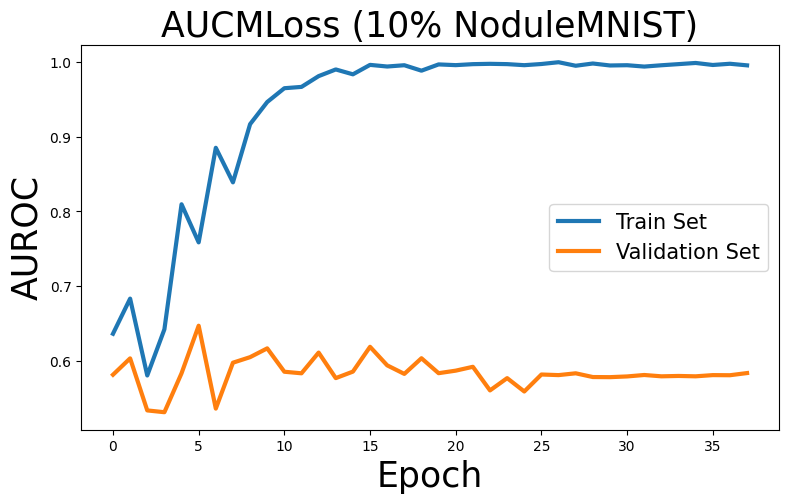

In [ ]:
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_log))
plt.figure()
plt.plot(x, train_log, linestyle='-', label='Train Set', linewidth=3)
plt.plot(x, val_log,  linestyle='-', label='Validation Set', linewidth=3)
plt.title('AUCMLoss (10% NoduleMNIST)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUROC', fontsize=25)
plt.xlabel('Epoch', fontsize=25)

In [ ]:
X_test = torch.from_numpy(test_dataset.imgs.astype(np.float32) / 255.0)
test_d = torch.utils.data.TensorDataset(X_test, torch.from_numpy(test_dataset.labels))

test_loader = data.DataLoader(dataset=test_d, batch_size=BATCH_SIZE)

# test ROC-AUC (the trainer already moved the model to `device`)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()  # eval mode: BatchNorm uses running statistics
score_list = list()
label_list = list()
for _, d in enumerate(test_loader, 0):
    tmp_data, tmp_label = d
    tmp_data = tmp_data.to(device)
    tmp_score = model(tmp_data).detach().clone().cpu()
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)

test_auc = metrics.roc_auc_score(test_label, test_score)
print("Test : %.4f"%test_auc, flush=True)

Test : 0.6152


In [ ]:
torch.save(model.state_dict(), "synapse/synapse_model1.pth")

### Model 2: flip + rotate

In [ ]:
# Model 2: flip (depth axis) + 3D rotation
train_d = OnTheFlyAugment(train_dataset1, make_augment([flip_aug, rotate_aug]))
# DualSampler: fixed class ratio per batch, see Overview
sampler_dual = DualSampler(train_d, batch_size=BATCH_SIZE, labels=train_dataset1.labels, sampling_rate=0.5)
trainloader = data.DataLoader(dataset=train_d, batch_size=BATCH_SIZE, sampler=sampler_dual)
valloader = data.DataLoader(dataset=val_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
trainloader_eval = data.DataLoader(train_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
# ResNet-20: CIFAR-style stem, see Overview
model2 = ResNet20(pretrained=False, last_activation=None, num_classes=1)
model2.conv1 = torch.nn.Conv2d(X_train.shape[1], 16, kernel_size=3, stride=1, padding=1, bias=False)


# hyperparameters (hand-picked)
total_epochs = 50
decay_epochs = [25, 40]  # 50% / 80% of total_epochs

lr = 0.05
margin = 1.0
epoch_decay = 0.003  # PESG's gamma
weight_decay = 0.0005


# loss and optimizer
loss_fn = AUCMLoss_V2(margin=margin)  # needs DualSampler (see Overview)
optimizer = PESG(model2,
                 loss_fn=loss_fn,
                 lr=lr,
                 momentum=0.9,
                 margin=margin,
                 epoch_decay=epoch_decay,
                 weight_decay=weight_decay)

In [ ]:
patience=12
train_log, val_log = train(model2, loss_fn, optimizer, total_epochs, trainloader, trainloader_eval,
                           valloader, patience=patience, decay_epochs=decay_epochs)

Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.9131, train_auc: 0.6203, val_auc: 0.5460, lr: 0.0500
0
epoch: 1, train_loss: 0.9115, train_auc: 0.6489, val_auc: 0.5581, lr: 0.0500
0
epoch: 2, train_loss: 0.8481, train_auc: 0.6418, val_auc: 0.6040, lr: 0.0500
0
epoch: 3, train_loss: 0.8169, train_auc: 0.6736, val_auc: 0.6227, lr: 0.0500
0
epoch: 4, train_loss: 0.7606, train_auc: 0.7160, val_auc: 0.6660, lr: 0.0500
0
epoch: 5, train_loss: 0.7085, train_auc: 0.7357, val_auc: 0.6281, lr: 0.0500
1
epoch: 6, train_loss: 0.6801, train_auc: 0.5439, val_auc: 0.6059, lr: 0.0500
2
epoch: 7, train_loss: 0.6708, train_auc: 0.7860, val_auc: 0.6379, lr: 0.0500
0
epoch: 8, train_loss: 0.6254, train_auc: 0.7920, val_auc: 0.5804, lr: 0.0500
1
epoch: 9, train_loss: 0.6012, train_auc: 0.6335, val_auc: 0.6095, lr: 0.0500
0
epoch: 10, train_loss: 0.5673, train_auc: 0.7532, val_auc: 0.6274, lr: 0.0500
0
epoch: 11, train_loss: 0.5369, train_auc: 0.7884, val_auc: 0.6021, lr: 

Text(0.5, 0, 'Epoch')

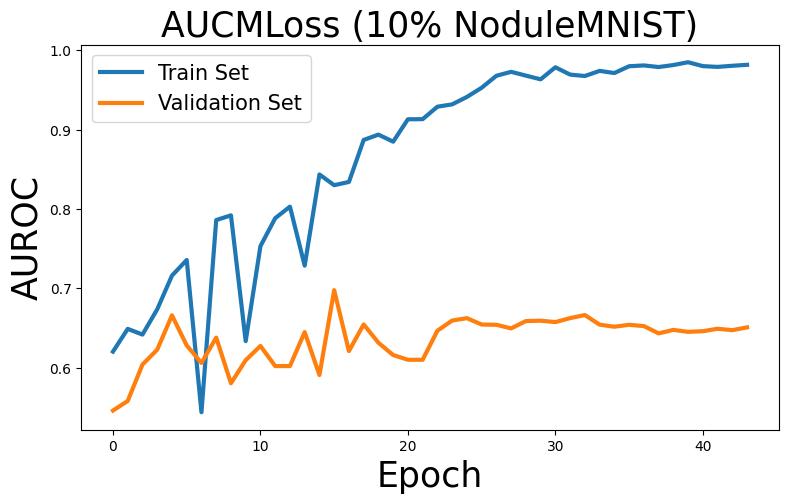

In [ ]:
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_log))
plt.figure()
plt.plot(x, train_log, linestyle='-', label='Train Set', linewidth=3)
plt.plot(x, val_log,  linestyle='-', label='Validation Set', linewidth=3)
plt.title('AUCMLoss (10% NoduleMNIST)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUROC', fontsize=25)
plt.xlabel('Epoch', fontsize=25)

In [ ]:
X_test = torch.from_numpy(test_dataset.imgs.astype(np.float32) / 255.0)
test_d = torch.utils.data.TensorDataset(X_test, torch.from_numpy(test_dataset.labels))

test_loader = data.DataLoader(dataset=test_d, batch_size=BATCH_SIZE)

# test ROC-AUC (the trainer already moved the model to `device`)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model2.eval()  # eval mode: BatchNorm uses running statistics
score_list = list()
label_list = list()
for _, d in enumerate(test_loader, 0):
    tmp_data, tmp_label = d
    tmp_data = tmp_data.to(device)
    tmp_score = model2(tmp_data).detach().clone().cpu()
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)

test_auc = metrics.roc_auc_score(test_label, test_score)
print("Test : %.4f"%test_auc, flush=True)

Test : 0.7386


In [ ]:
torch.save(model2.state_dict(), "synapse/synapse_model2.pth")

### Model 3: noise + elastic

In [ ]:
# Model 3: Gaussian noise + 3D elastic deformation
train_d = OnTheFlyAugment(train_dataset1, make_augment([noise_aug, elastic_aug]))
# DualSampler: fixed class ratio per batch, see Overview
sampler_dual = DualSampler(train_d, batch_size=BATCH_SIZE, labels=train_dataset1.labels, sampling_rate=0.5)
trainloader = data.DataLoader(dataset=train_d, batch_size=BATCH_SIZE, sampler=sampler_dual)
valloader = data.DataLoader(dataset=val_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
trainloader_eval = data.DataLoader(train_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
# ResNet-20: CIFAR-style stem, see Overview
model3 = ResNet20(pretrained=False, last_activation=None, num_classes=1)
model3.conv1 = torch.nn.Conv2d(X_train.shape[1], 16, kernel_size=3, stride=1, padding=1, bias=False)


# hyperparameters (hand-picked)
total_epochs = 50
decay_epochs = [25, 40]  # 50% / 80% of total_epochs

lr = 0.05
margin = 1.0
epoch_decay = 0.003  # PESG's gamma
weight_decay = 0.0005


# loss and optimizer
loss_fn = AUCMLoss_V2(margin=margin)  # needs DualSampler (see Overview)
optimizer = PESG(model3,
                 loss_fn=loss_fn,
                 lr=lr,
                 momentum=0.9,
                 margin=margin,
                 epoch_decay=epoch_decay,
                 weight_decay=weight_decay)

In [ ]:
patience=12
train_log, val_log = train(model3, loss_fn, optimizer, total_epochs, trainloader, trainloader_eval,
                           valloader, patience=patience, decay_epochs=decay_epochs)

Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.8719, train_auc: 0.6668, val_auc: 0.5420, lr: 0.0500
0
epoch: 1, train_loss: 0.7009, train_auc: 0.6552, val_auc: 0.4485, lr: 0.0500
1
epoch: 2, train_loss: 0.4232, train_auc: 0.7759, val_auc: 0.5296, lr: 0.0500
0
epoch: 3, train_loss: 0.1517, train_auc: 0.9663, val_auc: 0.6316, lr: 0.0500
0
epoch: 4, train_loss: 0.0557, train_auc: 0.9890, val_auc: 0.5255, lr: 0.0500
1
epoch: 5, train_loss: 0.0321, train_auc: 0.9902, val_auc: 0.5141, lr: 0.0500
2
epoch: 6, train_loss: 0.0202, train_auc: 0.9915, val_auc: 0.5255, lr: 0.0500
0
epoch: 7, train_loss: 0.0185, train_auc: 0.9940, val_auc: 0.5213, lr: 0.0500
1
epoch: 8, train_loss: 0.0141, train_auc: 0.9943, val_auc: 0.5515, lr: 0.0500
0
epoch: 9, train_loss: 0.0163, train_auc: 0.9959, val_auc: 0.4545, lr: 0.0500
1
epoch: 10, train_loss: 0.0119, train_auc: 0.9967, val_auc: 0.5506, lr: 0.0500
0
epoch: 11, train_loss: 0.0156, train_auc: 0.9990, val_auc: 0.5451, lr: 

Text(0.5, 0, 'Epoch')

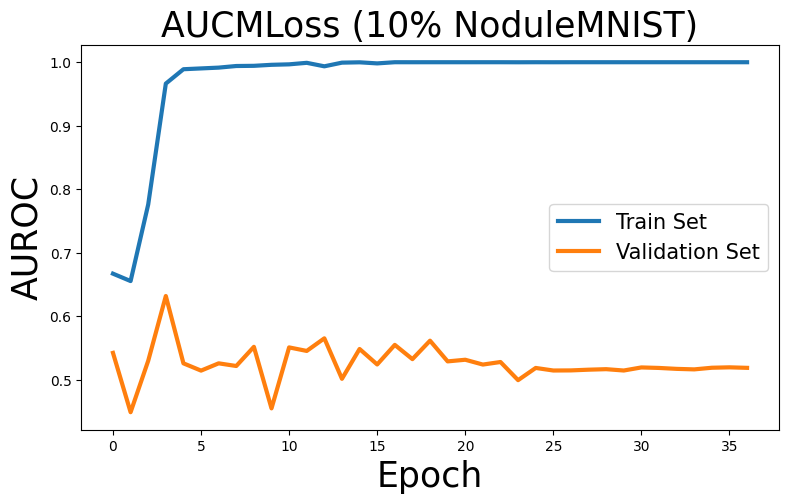

In [ ]:
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_log))
plt.figure()
plt.plot(x, train_log, linestyle='-', label='Train Set', linewidth=3)
plt.plot(x, val_log,  linestyle='-', label='Validation Set', linewidth=3)
plt.title('AUCMLoss (10% NoduleMNIST)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUROC', fontsize=25)
plt.xlabel('Epoch', fontsize=25)

In [ ]:
X_test = torch.from_numpy(test_dataset.imgs.astype(np.float32) / 255.0)
test_d = torch.utils.data.TensorDataset(X_test, torch.from_numpy(test_dataset.labels))

test_loader = data.DataLoader(dataset=test_d, batch_size=BATCH_SIZE)

# test ROC-AUC (the trainer already moved the model to `device`)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model3.eval()  # eval mode: BatchNorm uses running statistics
score_list = list()
label_list = list()
for _, d in enumerate(test_loader, 0):
    tmp_data, tmp_label = d
    tmp_data = tmp_data.to(device)
    tmp_score = model3(tmp_data).detach().clone().cpu()
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)

test_auc = metrics.roc_auc_score(test_label, test_score)
print("Test : %.4f"%test_auc, flush=True)

Test : 0.5790


In [ ]:
torch.save(model3.state_dict(), "synapse/synapse_model3.pth")

### Model 4: flip + noise + rotate + elastic

In [ ]:
# Model 4: flip (depth axis) + Gaussian noise + 3D rotation + 3D elastic deformation
train_d = OnTheFlyAugment(train_dataset1, make_augment([flip_aug, noise_aug, rotate_aug, elastic_aug]))
# DualSampler: fixed class ratio per batch, see Overview
sampler_dual = DualSampler(train_d, batch_size=BATCH_SIZE, labels=train_dataset1.labels, sampling_rate=0.5)
trainloader = data.DataLoader(dataset=train_d, batch_size=BATCH_SIZE, sampler=sampler_dual)
valloader = data.DataLoader(dataset=val_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
trainloader_eval = data.DataLoader(train_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
# ResNet-20: CIFAR-style stem, see Overview
model4 = ResNet20(pretrained=False, last_activation=None, num_classes=1)
model4.conv1 = torch.nn.Conv2d(X_train.shape[1], 16, kernel_size=3, stride=1, padding=1, bias=False)


# hyperparameters (hand-picked)
total_epochs = 50
decay_epochs = [25, 40]  # 50% / 80% of total_epochs

lr = 0.05
margin = 1.0
epoch_decay = 0.003  # PESG's gamma
weight_decay = 0.0005


# loss and optimizer
loss_fn = AUCMLoss_V2(margin=margin)  # needs DualSampler (see Overview)
optimizer = PESG(model4,
                 loss_fn=loss_fn,
                 lr=lr,
                 momentum=0.9,
                 margin=margin,
                 epoch_decay=epoch_decay,
                 weight_decay=weight_decay)

In [ ]:
patience=12
train_log, val_log = train(model4, loss_fn, optimizer, total_epochs, trainloader, trainloader_eval,
                           valloader, patience=patience, decay_epochs=decay_epochs)

Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.8959, train_auc: 0.5906, val_auc: 0.5018, lr: 0.0500
0
epoch: 1, train_loss: 0.8674, train_auc: 0.6425, val_auc: 0.5706, lr: 0.0500
0
epoch: 2, train_loss: 0.7847, train_auc: 0.6202, val_auc: 0.5635, lr: 0.0500
1
epoch: 3, train_loss: 0.7789, train_auc: 0.7365, val_auc: 0.6680, lr: 0.0500
0
epoch: 4, train_loss: 0.7012, train_auc: 0.7373, val_auc: 0.6476, lr: 0.0500
1
epoch: 5, train_loss: 0.6988, train_auc: 0.7343, val_auc: 0.6106, lr: 0.0500
2
epoch: 6, train_loss: 0.6617, train_auc: 0.5833, val_auc: 0.5745, lr: 0.0500
3
epoch: 7, train_loss: 0.6703, train_auc: 0.7335, val_auc: 0.6048, lr: 0.0500
0
epoch: 8, train_loss: 0.5861, train_auc: 0.7507, val_auc: 0.5814, lr: 0.0500
1
epoch: 9, train_loss: 0.5940, train_auc: 0.7490, val_auc: 0.5662, lr: 0.0500
2
epoch: 10, train_loss: 0.5581, train_auc: 0.7658, val_auc: 0.6300, lr: 0.0500
0
epoch: 11, train_loss: 0.5320, train_auc: 0.7702, val_auc: 0.6389, lr: 

Text(0.5, 0, 'Epoch')

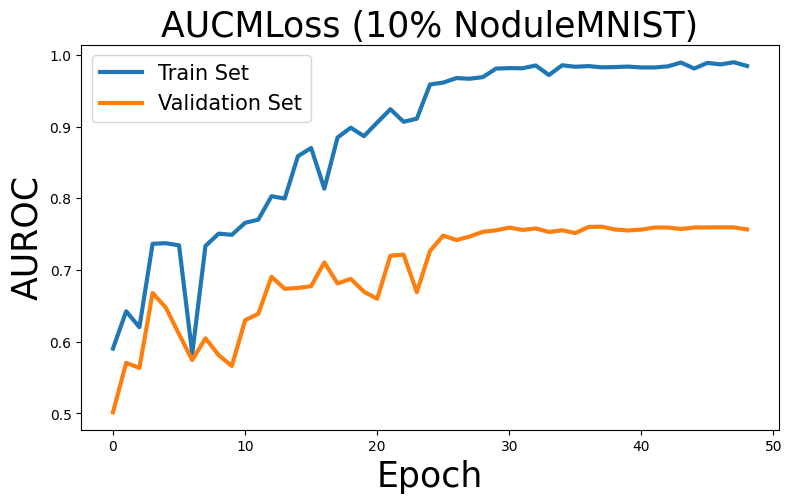

In [ ]:
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_log))
plt.figure()
plt.plot(x, train_log, linestyle='-', label='Train Set', linewidth=3)
plt.plot(x, val_log,  linestyle='-', label='Validation Set', linewidth=3)
plt.title('AUCMLoss (10% NoduleMNIST)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUROC', fontsize=25)
plt.xlabel('Epoch', fontsize=25)

In [ ]:
X_test = torch.from_numpy(test_dataset.imgs.astype(np.float32) / 255.0)
test_d = torch.utils.data.TensorDataset(X_test, torch.from_numpy(test_dataset.labels))

test_loader = data.DataLoader(dataset=test_d, batch_size=BATCH_SIZE)

# test ROC-AUC (the trainer already moved the model to `device`)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model4.eval()  # eval mode: BatchNorm uses running statistics
score_list = list()
label_list = list()
for _, d in enumerate(test_loader, 0):
    tmp_data, tmp_label = d
    tmp_data = tmp_data.to(device)
    tmp_score = model4(tmp_data).detach().clone().cpu()
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)

test_auc = metrics.roc_auc_score(test_label, test_score)
print("Test : %.4f"%test_auc, flush=True)

Test : 0.7645


In [ ]:
torch.save(model4.state_dict(), "synapse/synapse_model4.pth")

## No-augmentation ablation

The Model 1 recipe with `make_augment([])`, so volumes are only converted to tensors. This isolates the effect of augmentation.

In [ ]:
# no augmentation: make_augment([]) only converts to a tensor and drops the channel dim
train_d_noaug = OnTheFlyAugment(train_dataset1, make_augment([]))
# DualSampler: fixed class ratio per batch, see Overview
sampler_dual = DualSampler(train_d_noaug, batch_size=BATCH_SIZE, labels=train_dataset1.labels, sampling_rate=0.5)
trainloader_noaug = data.DataLoader(dataset=train_d_noaug, batch_size=BATCH_SIZE, sampler=sampler_dual)
valloader_noaug = data.DataLoader(dataset=val_d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
trainloader_eval_noaug = data.DataLoader(train_d_noaug, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
# ResNet-20: CIFAR-style stem, see Overview
model5 = ResNet20(pretrained=False, last_activation=None, num_classes=1)
model5.conv1 = torch.nn.Conv2d(X_train.shape[1], 16, kernel_size=3, stride=1, padding=1, bias=False)


# same hyperparameters as Model 1
total_epochs = 50
decay_epochs = [25, 40]

lr = 0.05
margin = 1.0
epoch_decay = 0.003
weight_decay = 0.0005


# loss and optimizer
loss_fn = AUCMLoss_V2(margin=margin)  # needs DualSampler (see Overview)
optimizer = PESG(model5,
                 loss_fn=loss_fn,
                 lr=lr,
                 momentum=0.9,
                 margin=margin,
                 epoch_decay=epoch_decay,
                 weight_decay=weight_decay)

In [ ]:
patience=12
train_log, val_log = train(model5, loss_fn, optimizer, total_epochs, trainloader_noaug, trainloader_eval_noaug,
                           valloader_noaug, patience=patience, decay_epochs=decay_epochs)

Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.8909, train_auc: 0.6305, val_auc: 0.5412, lr: 0.0500
0
epoch: 1, train_loss: 0.7294, train_auc: 0.5878, val_auc: 0.5770, lr: 0.0500
0
epoch: 2, train_loss: 0.4918, train_auc: 0.7691, val_auc: 0.5901, lr: 0.0500
0
epoch: 3, train_loss: 0.2596, train_auc: 0.9169, val_auc: 0.5362, lr: 0.0500
1
epoch: 4, train_loss: 0.1178, train_auc: 0.9709, val_auc: 0.6058, lr: 0.0500
0
epoch: 5, train_loss: 0.0382, train_auc: 0.9894, val_auc: 0.5594, lr: 0.0500
1
epoch: 6, train_loss: 0.0171, train_auc: 0.9942, val_auc: 0.5625, lr: 0.0500
2
epoch: 7, train_loss: 0.0098, train_auc: 0.9951, val_auc: 0.5625, lr: 0.0500
3
epoch: 8, train_loss: 0.0092, train_auc: 0.9955, val_auc: 0.5656, lr: 0.0500
4
epoch: 9, train_loss: 0.0088, train_auc: 0.9966, val_auc: 0.5583, lr: 0.0500
5
epoch: 10, train_loss: 0.0064, train_auc: 0.9965, val_auc: 0.5680, lr: 0.0500
0
epoch: 11, train_loss: 0.0036, train_auc: 0.9967, val_auc: 0.5803, lr: 

Text(0.5, 0, 'Epoch')

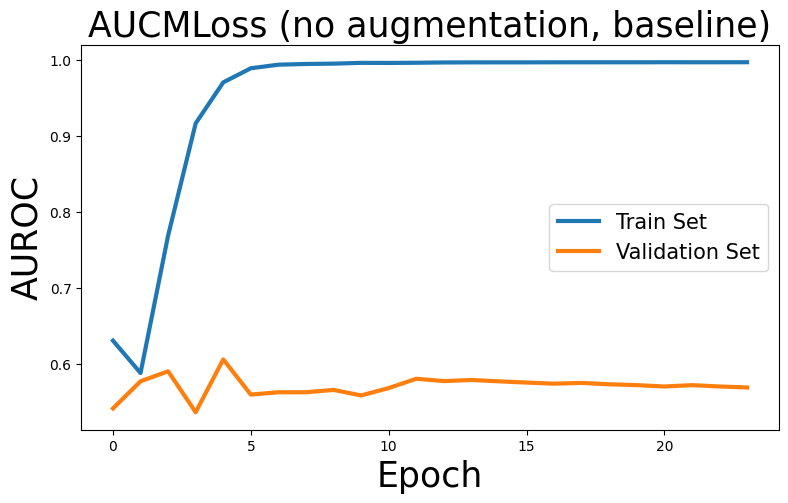

In [ ]:
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_log))
plt.figure()
plt.plot(x, train_log, linestyle='-', label='Train Set', linewidth=3)
plt.plot(x, val_log,  linestyle='-', label='Validation Set', linewidth=3)
plt.title('AUCMLoss (no augmentation, baseline)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUROC', fontsize=25)
plt.xlabel('Epoch', fontsize=25)

In [ ]:
X_test = torch.from_numpy(test_dataset.imgs.astype(np.float32) / 255.0)
test_d = torch.utils.data.TensorDataset(X_test, torch.from_numpy(test_dataset.labels))

test_loader = data.DataLoader(dataset=test_d, batch_size=BATCH_SIZE)

# test ROC-AUC (the trainer already moved the model to `device`)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model5.eval()  # eval mode: BatchNorm uses running statistics
score_list = list()
label_list = list()
for _, d in enumerate(test_loader, 0):
    tmp_data, tmp_label = d
    tmp_data = tmp_data.to(device)
    tmp_score = model5(tmp_data).detach().clone().cpu()
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)

test_auc = metrics.roc_auc_score(test_label, test_score)
print("Test (no augmentation) : %.4f"%test_auc, flush=True)

Test (no augmentation) : 0.6373


In [ ]:
torch.save(model5.state_dict(), "synapse/synapse_model5_noaug.pth")

## Hand-picked Conv3d

The 2.5D models feed the 28 depth slices in as channels, so `conv1` mixes all slices and the 2D convolutions after it never slide along depth. Here the backbone is `torchvision.models.video.r3d_18` (ResNet-18 from `Conv3d`/`BatchNorm3d`, `weights=None`) with a one-channel stem (`Conv3d(1, 64, kernel (3, 7, 7), stride (1, 2, 2))`) and one output logit.

The recipe is Model 4's (`AUCMLoss_V2(margin=1.0)` + `PESG`, lr 0.05, momentum 0.9, epoch_decay 0.003, weight decay 5e-4, `DualSampler` at 0.5, all four augmentations, batch size 32, up to 50 epochs, lr decay at 25 and 40, patience 12), so only the backbone changes.

It ran all 50 epochs. Only test ROC-AUC is computed.

In [ ]:
from torchvision.models.video import r3d_18

# like make_augment but keeps the channel dim (1, D, H, W), since Conv3d needs it
def make_augment_conv3d(funcs):
    def augment(img):
        if isinstance(img, np.ndarray):
            img = torch.from_numpy(img)
        img = img.float()
        for f in funcs:
            img = f(img)
        return img  # channel dim kept
    return augment

# all four augmentations, as in Model 4
train_d_3d = OnTheFlyAugment(train_dataset1, make_augment_conv3d([flip_aug, noise_aug, rotate_aug, elastic_aug]))

# DualSampler: fixed class ratio per batch, see Overview
sampler_3d = DualSampler(train_d_3d, batch_size=BATCH_SIZE, labels=train_dataset1.labels, sampling_rate=0.5)
trainloader_3d = data.DataLoader(dataset=train_d_3d, batch_size=BATCH_SIZE, sampler=sampler_3d)
trainloader_eval_3d = data.DataLoader(train_d_3d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

val_imgs_3d = torch.from_numpy(val_dataset1.imgs.astype(np.float32) / 255.0).unsqueeze(1)  # (N, D, H, W) -> (N, 1, D, H, W)
val_labels_3d = torch.from_numpy(val_dataset1.labels)
val_d_3d = torch.utils.data.TensorDataset(val_imgs_3d, val_labels_3d)
valloader_3d = data.DataLoader(dataset=val_d_3d, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
model_conv3d = r3d_18(weights=None)  # trained from scratch
# 1-channel input stem and a single-logit head
model_conv3d.stem[0] = torch.nn.Conv3d(1, 64, kernel_size=(3, 7, 7), stride=(1, 2, 2), padding=(1, 3, 3), bias=False)
model_conv3d.fc = torch.nn.Linear(model_conv3d.fc.in_features, 1)

# same hyperparameters and schedule as Model 4
total_epochs = 50
decay_epochs = [25, 40]

lr = 0.05
margin = 1.0
epoch_decay = 0.003
weight_decay = 0.0005

loss_fn = AUCMLoss_V2(margin=margin)  # needs DualSampler (see Overview)
optimizer = PESG(model_conv3d,
                 loss_fn=loss_fn,
                 lr=lr,
                 momentum=0.9,
                 margin=margin,
                 epoch_decay=epoch_decay,
                 weight_decay=weight_decay)

In [52]:
patience = 12
train_log_3d, val_log_3d = train(model_conv3d, loss_fn, optimizer, total_epochs, trainloader_3d,
                                  trainloader_eval_3d, valloader_3d, patience=patience, decay_epochs=decay_epochs)

Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.9136, train_auc: 0.4855, val_auc: 0.3900, lr: 0.0500
0
epoch: 1, train_loss: 1.0000, train_auc: 0.4794, val_auc: 0.3889, lr: 0.0500
1
epoch: 2, train_loss: 1.0000, train_auc: 0.4400, val_auc: 0.3876, lr: 0.0500
2
epoch: 3, train_loss: 1.0000, train_auc: 0.4693, val_auc: 0.3881, lr: 0.0500
3
epoch: 4, train_loss: 1.0000, train_auc: 0.4945, val_auc: 0.3903, lr: 0.0500
4
epoch: 5, train_loss: 1.0000, train_auc: 0.4566, val_auc: 0.3923, lr: 0.0500
5
epoch: 6, train_loss: 1.0001, train_auc: 0.5172, val_auc: 0.3936, lr: 0.0500
6
epoch: 7, train_loss: 1.0000, train_auc: 0.4950, val_auc: 0.3929, lr: 0.0500
7
epoch: 8, train_loss: 1.0000, train_auc: 0.5056, val_auc: 0.3994, lr: 0.0500
0
epoch: 9, train_loss: 1.0000, train_auc: 0.5296, val_auc: 0.4020, lr: 0.0500
1
epoch: 10, train_loss: 1.0000, train_auc: 0.4983, val_auc: 0.4107, lr: 0.0500
0
epoch: 11, train_loss: 1.0000, train_auc: 0.5341, val_auc: 0.4172, lr: 

Text(0.5, 0, 'Epoch')

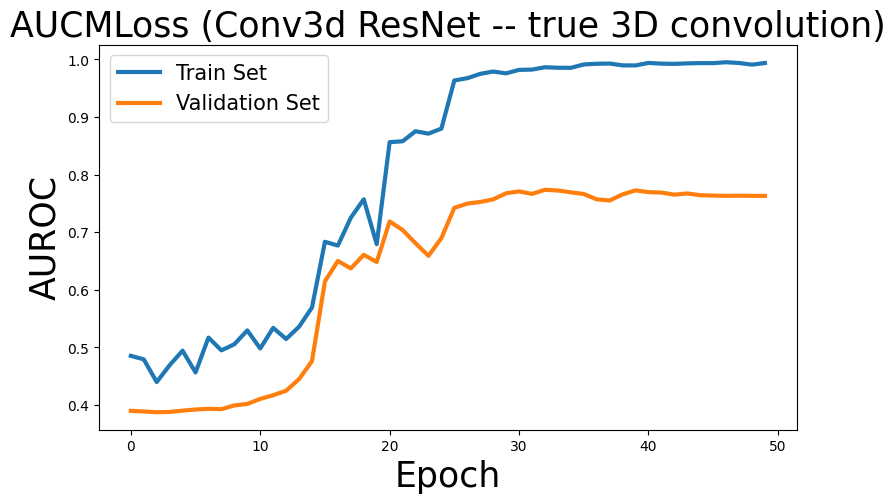

In [53]:
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_log_3d))
plt.figure()
plt.plot(x, train_log_3d, linestyle='-', label='Train Set', linewidth=3)
plt.plot(x, val_log_3d,  linestyle='-', label='Validation Set', linewidth=3)
plt.title('AUCMLoss (Conv3d ResNet -- true 3D convolution)',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUROC', fontsize=25)
plt.xlabel('Epoch', fontsize=25)

In [54]:
X_test_3d = torch.from_numpy(test_dataset.imgs.astype(np.float32) / 255.0).unsqueeze(1)  # (N, D, H, W) -> (N, 1, D, H, W)
test_d_3d = torch.utils.data.TensorDataset(X_test_3d, torch.from_numpy(test_dataset.labels))
test_loader_3d = data.DataLoader(dataset=test_d_3d, batch_size=BATCH_SIZE)

# test ROC-AUC (the trainer already moved the model to `device`)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_conv3d.eval()  # eval mode: BatchNorm uses running statistics
score_list = list()
label_list = list()
for _, d in enumerate(test_loader_3d, 0):
    tmp_data, tmp_label = d
    tmp_data = tmp_data.to(device)
    tmp_score = model_conv3d(tmp_data).detach().clone().cpu()
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)

test_auc = metrics.roc_auc_score(test_label, test_score)
print("Test (Conv3d ResNet) : %.4f"%test_auc, flush=True)

Test (Conv3d ResNet) : 0.7601


In [55]:
torch.save(model_conv3d.state_dict(), "synapse/synapse_model_conv3d.pth")

## Optuna tuning

An [Optuna](https://optuna.org/) search over the training hyperparameters of the Conv3d model (Model 4 recipe). Architecture, loss and augmentation are fixed.
- Search space: `batch_size` in {16, 32, 64}, `lr` log-uniform in [0.02, 0.15], `weight_decay` log-uniform in [2e-4, 1.5e-3], `margin` uniform in [0.8, 1.3], `epoch_decay` log-uniform in [1e-3, 8e-3]. `sampling_rate` stays 0.5 and momentum 0.9.
- Budget: 30 trials, `TPESampler` with 10 random startup trials. Each trial trains up to 10 epochs with lr decay at 5 and 8 and patience 4. A trial that raises `ValueError` (for example a NaN loss) is recorded as failed. The objective is the maximum validation ROC-AUC in the trial.
- Best trial: batch size 32, lr 0.0246, weight decay 4.46e-04, margin 1.19, epoch_decay 1.52e-03, search score 0.774. It is retrained with the full hand-picked budget (up to 50 epochs, decay at 25 and 40, patience 12) and tested.
- Trial scores run from 0.406 to 0.774. 13 of 30 trials scored below 0.5, all with lr of at least 0.0315. The best lr and epoch_decay sit near the lower ends of their ranges.

The search score is a maximum over epochs on 177 validation volumes, so it is optimistic. The retrained model's validation AUC is 0.747.

In [57]:
# build_model: fresh Conv3d ResNet per trial, same as model_conv3d
# no trial.suggest_* here, only training hyperparameters are tuned
def build_model(trial):
    model = r3d_18(weights=None)
    model.stem[0] = torch.nn.Conv3d(1, 64, kernel_size=(3, 7, 7), stride=(1, 2, 2), padding=(1, 3, 3), bias=False)
    model.fc = torch.nn.Linear(model.fc.in_features, 1)
    return model


# build_loaders: new pipeline per trial since batch_size is searched (sampling_rate fixed at 0.5)
def build_loaders(trial):
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    train_d_3d_trial = OnTheFlyAugment(
        train_dataset1, make_augment_conv3d([flip_aug, noise_aug, rotate_aug, elastic_aug])
    )
    sampler_3d_trial = DualSampler(
        train_d_3d_trial, batch_size=batch_size, labels=train_dataset1.labels, sampling_rate=0.5
    )
    trainloader_3d_trial = data.DataLoader(
        dataset=train_d_3d_trial, batch_size=batch_size, sampler=sampler_3d_trial
    )
    trainloader_eval_3d_trial = data.DataLoader(
        train_d_3d_trial, batch_size=batch_size, shuffle=False, num_workers=2
    )

    val_imgs_3d_trial = torch.from_numpy(val_dataset1.imgs.astype(np.float32) / 255.0).unsqueeze(1)  # (N, D, H, W) -> (N, 1, D, H, W)
    val_labels_3d_trial = torch.from_numpy(val_dataset1.labels)
    val_d_3d_trial = torch.utils.data.TensorDataset(val_imgs_3d_trial, val_labels_3d_trial)
    valloader_3d_trial = data.DataLoader(
        dataset=val_d_3d_trial, batch_size=batch_size, shuffle=False, num_workers=2
    )

    return trainloader_3d_trial, trainloader_eval_3d_trial, valloader_3d_trial


# lr, weight_decay and epoch_decay within about 3x of the hand-picked values, margin in [0.8, 1.3]
# PESG takes the model itself, not model.parameters()
def build_loss_optimizer(trial, model):
    lr = trial.suggest_float('lr', 2e-2, 1.5e-1, log=True)
    weight_decay = trial.suggest_float('weight_decay', 2e-4, 1.5e-3, log=True)
    margin = trial.suggest_float('margin', 0.8, 1.3)
    epoch_decay = trial.suggest_float('epoch_decay', 1e-3, 8e-3, log=True)

    loss_fn = AUCMLoss_V2(margin=margin)
    optimizer = PESG(
        model,
        loss_fn=loss_fn,
        lr=lr,
        momentum=0.9,
        margin=margin,
        epoch_decay=epoch_decay,
        weight_decay=weight_decay,
    )
    return loss_fn, optimizer


# score_fn: best validation ROC-AUC of the trial (train() restores the best checkpoint,
# train_fn_result[1] is the per-epoch validation AUC list)
def score_fn(model, valloader, train_fn_result):
    return max(train_fn_result[1])

In [58]:
from hyperparameter_tuning import run_optuna_search, retrain_with_best_params

# 30 trials (first 10 random, then TPE), each up to 10 epochs, lr decay at 5 and 8, patience 4
# catch=(ValueError,): a NaN loss makes roc_auc_score raise, the trial is recorded as failed
study = run_optuna_search(build_model, build_loaders, build_loss_optimizer, train, score_fn,
                           n_trials=30, search_epochs=10,
                           search_decay_epochs=[5, 8],
                           search_patience=4,
                           catch=(ValueError,))
print(study.best_params)
print(study.best_value)

[I 2026-09-24 10:37:46,695] A new study created in memory with name: no-name-c1fba2c0-4a6e-42d0-9d1d-71d7fdf1e42a


Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.7528, train_auc: 0.5406, val_auc: 0.4346, lr: 0.1255
0
epoch: 1, train_loss: 0.7745, train_auc: 0.5022, val_auc: 0.4369, lr: 0.1255
1
epoch: 2, train_loss: 0.7745, train_auc: 0.5015, val_auc: 0.4360, lr: 0.1255
2
epoch: 3, train_loss: 0.7745, train_auc: 0.4764, val_auc: 0.4385, lr: 0.1255
3


[I 2026-09-24 10:39:31,341] Trial 0 finished with value: 0.4391149870801033 and parameters: {'batch_size': 32, 'lr': 0.1254616277194227, 'weight_decay': 0.0004390934955380852, 'margin': 0.8800603027973353, 'epoch_decay': 0.005973944128468644}. Best is trial 0 with value: 0.4391149870801033.


epoch: 4, train_loss: 0.7745, train_auc: 0.4766, val_auc: 0.4391, lr: 0.1255
4
Early stopping
Restoring best checkpoint: epoch 4, val_auc 0.4391
Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 0.8240, train_auc: 0.5249, val_auc: 0.4617, lr: 0.1305
0
epoch: 1, train_loss: 0.8432, train_auc: 0.4940, val_auc: 0.4545, lr: 0.1305
1
epoch: 2, train_loss: 0.8432, train_auc: 0.4752, val_auc: 0.4562, lr: 0.1305
2
epoch: 3, train_loss: 0.8432, train_auc: 0.5015, val_auc: 0.4532, lr: 0.1305
3


[I 2026-09-24 10:41:15,719] Trial 1 finished with value: 0.46172480620155043 and parameters: {'batch_size': 32, 'lr': 0.13051132318569306, 'weight_decay': 0.0005945890942295854, 'margin': 0.9182364416543871, 'epoch_decay': 0.0012566037974973663}. Best is trial 1 with value: 0.46172480620155043.


...

epoch: 8, train_loss: 1.5972, train_auc: 0.5237, val_auc: 0.4501, lr: 0.0004
4
Early stopping
Restoring best checkpoint: epoch 0, val_auc 0.4627
Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 1.3438, train_auc: 0.5306, val_auc: 0.4557, lr: 0.0261
0
epoch: 1, train_loss: 1.6149, train_auc: 0.5124, val_auc: 0.4690, lr: 0.0261
0
epoch: 2, train_loss: 1.6047, train_auc: 0.6494, val_auc: 0.5628, lr: 0.0261
0
epoch: 3, train_loss: 1.4059, train_auc: 0.6913, val_auc: 0.6095, lr: 0.0261
0
epoch: 4, train_loss: 1.2636, train_auc: 0.7373, val_auc: 0.6214, lr: 0.0261
0
Reducing learning rate to 0.00261 @ T=280!
Updating regularizer @ T=280!
epoch: 5, train_loss: 1.0408, train_auc: 0.8064, val_auc: 0.6646, lr: 0.0026
0
epoch: 6, train_loss: 0.8966, train_auc: 0.8291, val_auc: 0.6804, lr: 0.0026
0
epoch: 7, train_loss: 0.8099, train_auc: 0.8560, val_auc: 0.6875, lr: 0.0026
0
Reducing learning rate to 0.00026 @ T=448!
Updating regularizer @ T=448!
epoch: 8, train_lo

[I 2026-09-24 12:00:12,249] Trial 28 finished with value: 0.6900839793281653 and parameters: {'batch_size': 32, 'lr': 0.02613686520071917, 'weight_decay': 0.0003423435472616104, 'margin': 1.271243731677567, 'epoch_decay': 0.0011745306151443539}. Best is trial 23 with value: 0.7737403100775193.


epoch: 9, train_loss: 0.7245, train_auc: 0.8695, val_auc: 0.6901, lr: 0.0003
2
Restoring best checkpoint: epoch 8, val_auc 0.6901
Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 1.3215, train_auc: 0.4799, val_auc: 0.4398, lr: 0.0286
0
epoch: 1, train_loss: 1.5591, train_auc: 0.5121, val_auc: 0.4461, lr: 0.0286
0
epoch: 2, train_loss: 1.5592, train_auc: 0.5142, val_auc: 0.4575, lr: 0.0286
0
epoch: 3, train_loss: 1.5582, train_auc: 0.5533, val_auc: 0.4738, lr: 0.0286
0
epoch: 4, train_loss: 1.5474, train_auc: 0.6373, val_auc: 0.5273, lr: 0.0286
0
Reducing learning rate to 0.00286 @ T=280!
Updating regularizer @ T=280!
epoch: 5, train_loss: 1.4360, train_auc: 0.6620, val_auc: 0.5602, lr: 0.0029
0
epoch: 6, train_loss: 1.3568, train_auc: 0.6819, val_auc: 0.5767, lr: 0.0029
0
epoch: 7, train_loss: 1.3138, train_auc: 0.6901, val_auc: 0.5812, lr: 0.0029
1
Reducing learning rate to 0.00029 @ T=448!
Updating regularizer @ T=448!
epoch: 8, train_loss: 1.3049, tra

[I 2026-09-24 12:03:39,846] Trial 29 finished with value: 0.5825258397932817 and parameters: {'batch_size': 32, 'lr': 0.02861192023945551, 'weight_decay': 0.000890248258265397, 'margin': 1.2487411636099046, 'epoch_decay': 0.0015883259211746852}. Best is trial 23 with value: 0.7737403100775193.


epoch: 9, train_loss: 1.2639, train_auc: 0.6934, val_auc: 0.5825, lr: 0.0003
3
Restoring best checkpoint: epoch 9, val_auc 0.5825
{'batch_size': 32, 'lr': 0.02464961667360378, 'weight_decay': 0.0004456573087101823, 'margin': 1.1884865542075667, 'epoch_decay': 0.0015234557703065268}
0.7737403100775193


In [60]:
# retrain the best params with the full budget (up to 50 epochs, decay at 25 and 40, patience 12)
model_conv3d_tuned, loss_fn_tuned, optimizer_tuned, (train_log_3d_tuned, val_log_3d_tuned) = retrain_with_best_params(
    study, build_model, build_loaders, build_loss_optimizer, train,
    full_epochs=50, full_decay_epochs=[25, 40], full_patience=12)

# best_params supplies the test-loader batch size below
best_params = study.best_params

Start Training
------------------------------
device: cuda
epoch: 0, train_loss: 1.1622, train_auc: 0.5442, val_auc: 0.4756, lr: 0.0246
0
epoch: 1, train_loss: 1.4107, train_auc: 0.5497, val_auc: 0.5120, lr: 0.0246
0
epoch: 2, train_loss: 1.3889, train_auc: 0.6630, val_auc: 0.5644, lr: 0.0246
0
epoch: 3, train_loss: 1.1870, train_auc: 0.7021, val_auc: 0.6411, lr: 0.0246
0
epoch: 4, train_loss: 1.0545, train_auc: 0.7477, val_auc: 0.6444, lr: 0.0246
1
epoch: 5, train_loss: 0.9918, train_auc: 0.7739, val_auc: 0.7196, lr: 0.0246
0
epoch: 6, train_loss: 0.8869, train_auc: 0.7443, val_auc: 0.6600, lr: 0.0246
1
epoch: 7, train_loss: 0.7655, train_auc: 0.8113, val_auc: 0.6705, lr: 0.0246
0
epoch: 8, train_loss: 0.7124, train_auc: 0.7816, val_auc: 0.6865, lr: 0.0246
0
epoch: 9, train_loss: 0.6106, train_auc: 0.8727, val_auc: 0.6494, lr: 0.0246
1
epoch: 10, train_loss: 0.5707, train_auc: 0.9137, val_auc: 0.7049, lr: 0.0246
0
epoch: 11, train_loss: 0.4839, train_auc: 0.8746, val_auc: 0.7288, lr: 

Text(0.5, 0, 'Epoch')

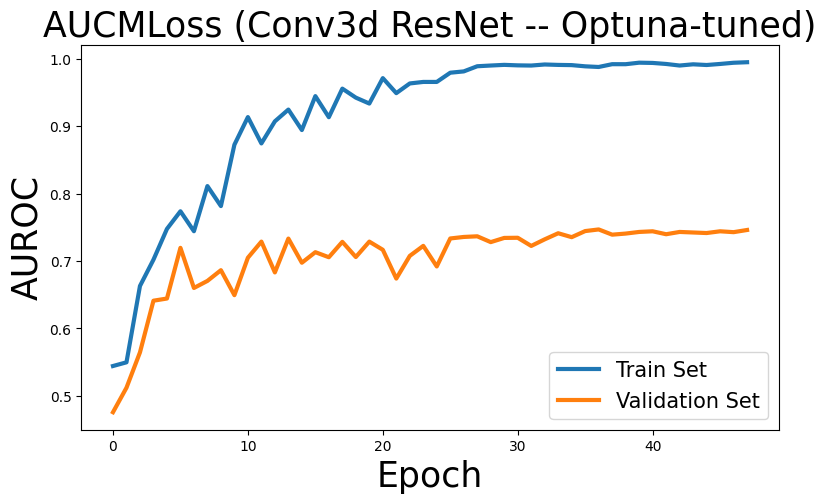

In [61]:

plt.rcParams["figure.figsize"] = (9,5)
x = np.arange(len(train_log_3d_tuned))
plt.figure()
plt.plot(x, train_log_3d_tuned, linestyle='-', label='Train Set', linewidth=3)
plt.plot(x, val_log_3d_tuned, linestyle='-', label='Validation Set', linewidth=3)
plt.title('AUCMLoss (Conv3d ResNet -- Optuna-tuned)', fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUROC', fontsize=25)
plt.xlabel('Epoch', fontsize=25)

In [62]:
X_test_3d_tuned = torch.from_numpy(test_dataset.imgs.astype(np.float32) / 255.0).unsqueeze(1)  # (N, D, H, W) -> (N, 1, D, H, W)
test_d_3d_tuned = torch.utils.data.TensorDataset(X_test_3d_tuned, torch.from_numpy(test_dataset.labels))
test_loader_3d_tuned = data.DataLoader(dataset=test_d_3d_tuned, batch_size=best_params['batch_size'])

# test ROC-AUC (the trainer already moved the model to `device`)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_conv3d_tuned.eval()  # eval mode: BatchNorm uses running statistics
score_list = list()
label_list = list()
for _, d in enumerate(test_loader_3d_tuned, 0):
    tmp_data, tmp_label = d
    tmp_data = tmp_data.to(device)
    tmp_score = model_conv3d_tuned(tmp_data).detach().clone().cpu()
    score_list.append(tmp_score)
    label_list.append(tmp_label.cpu())

test_label = torch.cat(label_list)
test_score = torch.cat(score_list)

test_auc = metrics.roc_auc_score(test_label, test_score)
print("Test (Conv3d ResNet, Optuna-tuned) : %.4f"%test_auc, flush=True)

Test (Conv3d ResNet, Optuna-tuned) : 0.7780


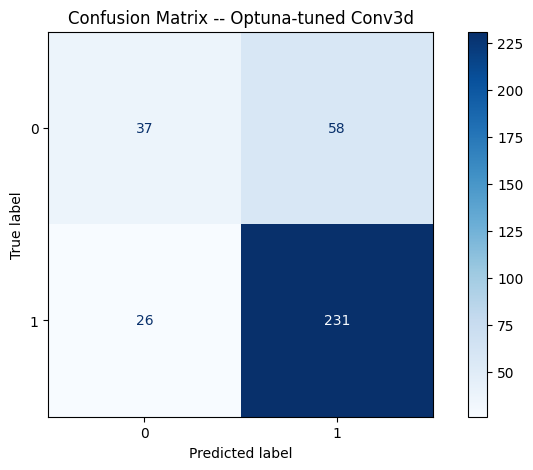

              precision    recall  f1-score   support

           0     0.5873    0.3895    0.4684        95
           1     0.7993    0.8988    0.8462       257

    accuracy                         0.7614       352
   macro avg     0.6933    0.6442    0.6573       352
weighted avg     0.7421    0.7614    0.7442       352

Balanced accuracy: 0.6442
PR-AUC (average precision): 0.8974
Matthews correlation coefficient: 0.3339


In [63]:
# confusion matrix and threshold metrics at 0.5
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              balanced_accuracy_score, average_precision_score, matthews_corrcoef)

prob = torch.sigmoid(test_score).numpy().reshape(-1)  # raw logit -> probability
y_true = test_label.numpy().astype(int).reshape(-1)
y_pred = (prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title('Confusion Matrix -- Optuna-tuned Conv3d')
plt.show()

# class 0 = inhibitory (minority), class 1 = excitatory (majority)
print(classification_report(y_true, y_pred, digits=4))
print('Balanced accuracy: %.4f' % balanced_accuracy_score(y_true, y_pred))
# PR-AUC is for label 1 (the majority), so it's high by construction. Minority class: see the class-0 row above
print('PR-AUC (average precision): %.4f' % average_precision_score(y_true, prob))
print('Matthews correlation coefficient: %.4f' % matthews_corrcoef(y_true, y_pred))

In [64]:
torch.save(model_conv3d_tuned.state_dict(), "synapse/synapse_model_conv3d_tuned.pth")

## Results

Test set: 352 volumes (95 inhibitory, 257 excitatory). Val AUC is the restored checkpoint's, with its 0-based epoch in parentheses. "-" means not computed.

| Arm | Val AUC (epoch) | Test ROC-AUC | Bal. acc. @0.5 | MCC @0.5 | PR-AUC (label 1) | Inhibitory recall / F1 @0.5 |
|---|---|---|---|---|---|---|
| Baseline (2.5D ResNet-18, BCE + Adam, no augmentation, no balancing) | 0.6591 (5) | 0.6259 | 0.5783 | 0.1413 | 0.8069 | 0.5263 / 0.4167 |
| Model 1: flip + noise (2.5D ResNet-20, AUCM) | 0.6468 (5) | 0.6152 | - | - | - | - |
| Model 2: flip + rotate | 0.6977 (15) | 0.7386 | - | - | - | - |
| Model 3: noise + elastic | 0.6316 (3) | 0.5790 | - | - | - | - |
| Model 4: flip + noise + rotate + elastic | 0.7603 (37) | 0.7645 | - | - | - | - |
| No-augmentation ablation | 0.6058 (4) | 0.6373 | - | - | - | - |
| Conv3d r3d_18, hand-picked | 0.7737 (32) | 0.7601 | - | - | - | - |
| Conv3d r3d_18, Optuna-tuned | 0.7469 (36) | 0.7780 | 0.6442 | 0.3339 | 0.8974 | 0.3895 / 0.4684 |

Only the Baseline and the Optuna-tuned Conv3d have every metric. PR-AUC is for label 1 (excitatory, 73% of the test set), so it is high by construction and says little about the minority class.

Optuna best params: batch size 32, lr 0.0246, weight decay 4.46e-04, margin 1.19, epoch_decay 1.52e-03 (search score 0.774).

### Takeaways

- The tuned Conv3d beats the Baseline on every metric except inhibitory recall (0.39 vs. 0.53), so there is no single winner. The arms differ in backbone, loss, optimizer, sampler and augmentation, so no one factor explains the gap.
- The tuned Conv3d has the highest test ROC-AUC (0.78), but Model 4 and the hand-picked Conv3d (both 0.76) are close, and validation AUC ranks the two Conv3d variants the other way (0.774 vs. 0.747). True 3D convolution shows no clear gain over Model 4, which has the same recipe.
- Rotation is in every arm that scores 0.74 to 0.78 (Model 2, Model 4, the Conv3d arms). Arms without it (Model 1, Model 3, no augmentation) score 0.58 to 0.64, like the Baseline (0.63). Their best validation epochs are 3 to 5.
- Balanced accuracy, MCC and inhibitory recall/F1 are at 0.5, so they also reflect where each arm's scores sit relative to 0.5. ROC-AUC is the cleaner comparison.

The test set is small (352 volumes, 95 inhibitory), so differences of a few hundredths in ROC-AUC shouldn't be over-read.